# Digital modulation comparison over AWGN

This notebook compares every modulation implemented by `pyberlab`: BPSK, QPSK, Gray-coded 8-PSK, 16-QAM, and 64-QAM. It connects constellation geometry and bits per symbol with the $E_b/N_0$ required to achieve a target bit-error rate (BER).

## Reliability and spectral-efficiency trade-off

Higher-order modulation carries more bits in each complex symbol, but places constellation points closer together at the same average symbol power. It therefore needs a larger $E_b/N_0$ to reach the same BER.

Bits per symbol are used here as a simple modulation-efficiency indicator. Actual bits/s/Hz also depends on pulse shaping, coding, guard intervals, and implementation details that this idealised experiment does not model.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "pyberlab").exists():
            return candidate
    raise RuntimeError("Run this notebook from inside the pyberlab repository.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from pyberlab.channel import awgn
from pyberlab.modulation import BPSK, PSK8, QAM16, QAM64, QPSK
from pyberlab.simulation import run_simulation
from pyberlab.theory import get_theory_fn

OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CONSTELLATION_PATH = OUTPUT_DIR / "modulation_constellations.png"
BER_FIGURE_PATH = OUTPUT_DIR / "modulation_ber_awgn.png"

MODULATIONS = {
    "BPSK": BPSK(),
    "QPSK": QPSK(),
    "8-PSK": PSK8(),
    "16-QAM": QAM16(),
    "64-QAM": QAM64(),
}
EBN0_DB = np.arange(0, 19, 2)
DENSE_EBN0_DB = np.linspace(0, 20, 401)
TARGET_BER = 1e-3
BASE_SEED = 31415

print(f"Comparing {len(MODULATIONS)} modulation schemes")
print(f"Target BER: {TARGET_BER:.0e}")

Comparing 5 modulation schemes
Target BER: 1e-03


## Compare constellation geometry

Every displayed constellation is normalised to unit average symbol power. The number of points doubles for every additional bit per symbol.

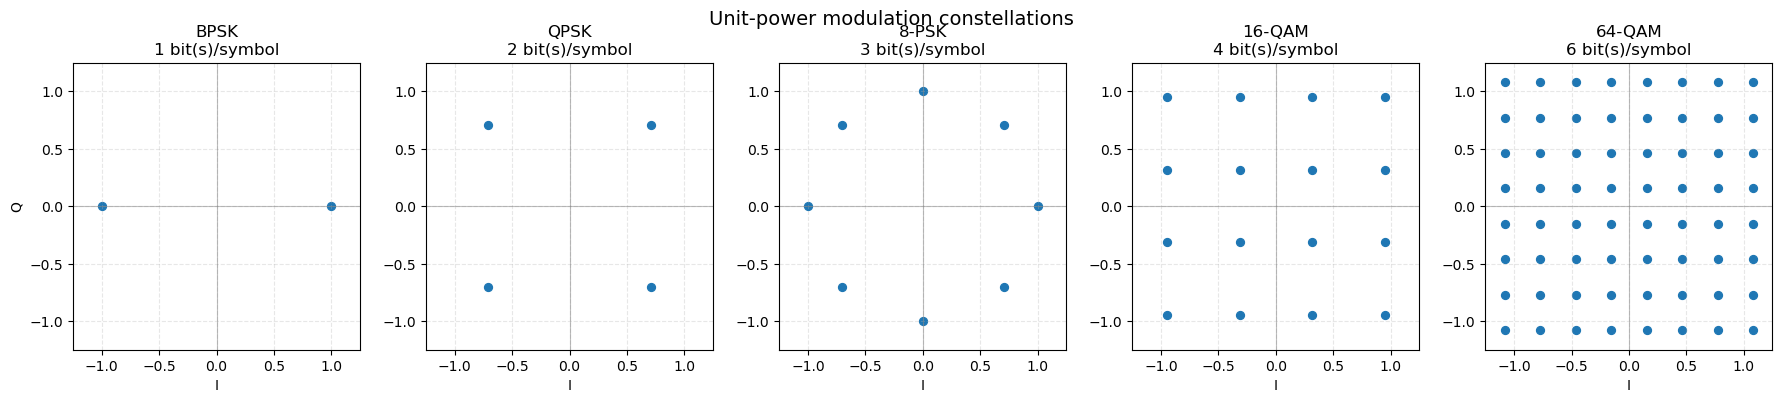

Saved constellations to outputs\modulation_constellations.png


In [3]:
def all_bit_patterns(bits_per_symbol: int) -> np.ndarray:
    labels = np.arange(2**bits_per_symbol, dtype=np.uint8)
    unpacked = np.unpackbits(labels[:, np.newaxis], axis=1, bitorder="big")
    return unpacked[:, -bits_per_symbol:]


fig, axes = plt.subplots(1, len(MODULATIONS), figsize=(18, 3.8))
for ax, (name, modulator) in zip(axes, MODULATIONS.items()):
    patterns = all_bit_patterns(modulator.bits_per_symbol)
    symbols = modulator.modulate(patterns.flatten())
    ax.scatter(np.real(symbols), np.imag(symbols), s=32)
    ax.axhline(0, color="gray", linewidth=0.8, alpha=0.5)
    ax.axvline(0, color="gray", linewidth=0.8, alpha=0.5)
    ax.set_title(f"{name}\n{modulator.bits_per_symbol} bit(s)/symbol")
    ax.set_xlabel("I")
    ax.set(xlim=(-1.25, 1.25), ylim=(-1.25, 1.25))
    ax.set_aspect("equal")
    ax.grid(True, linestyle="--", alpha=0.3)
axes[0].set_ylabel("Q")
fig.suptitle("Unit-power modulation constellations", fontsize=14)
fig.tight_layout()
fig.savefig(CONSTELLATION_PATH, dpi=150)
plt.show()
print(f"Saved constellations to {CONSTELLATION_PATH.relative_to(PROJECT_ROOT)}")

## Run AWGN simulations

Each scheme uses a deterministic seed and exports its own CSV file. The simulation grid is deliberately sparse for interactive speed; theory is evaluated on a dense grid for smooth curves and accurate target-BER interpolation.

In [4]:
results = {}
dense_theory = {}
dense_ebn0_linear = 10 ** (DENSE_EBN0_DB / 10)

for index, (name, modulator) in enumerate(MODULATIONS.items()):
    csv_name = f"comparison_{name.lower().replace('-', '')}_awgn.csv"
    print(f"Running {name:>6} ...")
    results[name] = run_simulation(
        modulator,
        awgn,
        EBN0_DB,
        seed=BASE_SEED + index,
        min_errors=150,
        max_bits=500_000,
        csv_path=OUTPUT_DIR / csv_name,
    )
    theory_fn = get_theory_fn(type(modulator).__name__, awgn.__name__)
    dense_theory[name] = np.asarray(theory_fn(dense_ebn0_linear))

print("All modulation experiments completed.")

Running   BPSK ...
Running   QPSK ...
Running  8-PSK ...
Running 16-QAM ...
Running 64-QAM ...
All modulation experiments completed.


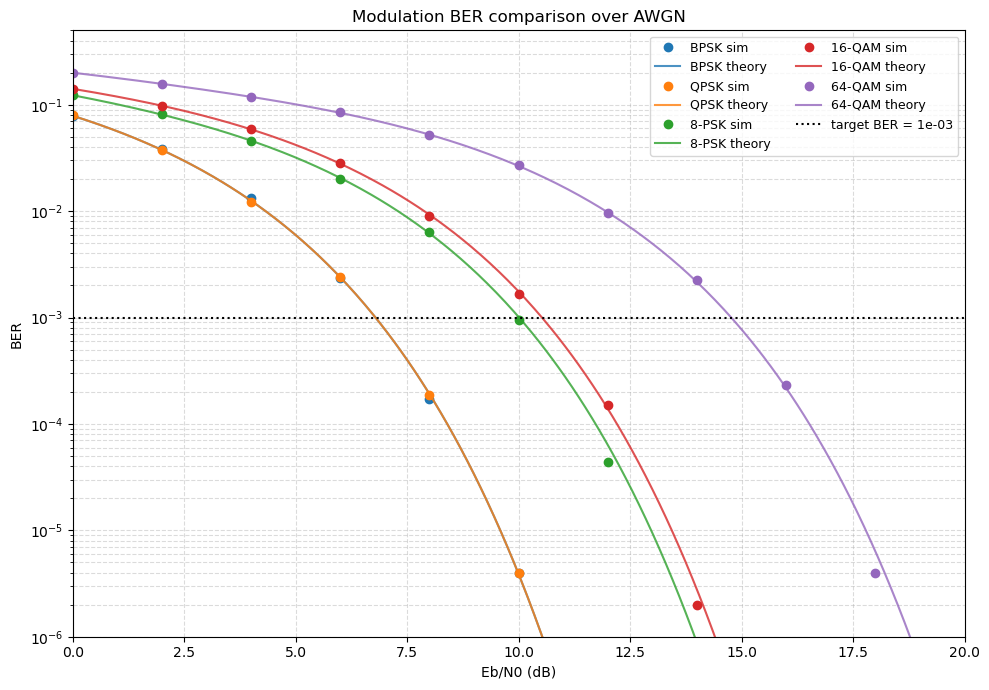

Saved BER figure to outputs\modulation_ber_awgn.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 7))
colours = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for colour, name in zip(colours, MODULATIONS):
    result = results[name]
    simulated = np.asarray(result["ber_sim"])
    simulated_for_plot = np.where(simulated > 0, simulated, np.nan)
    ax.semilogy(result["EbN0_dB"], simulated_for_plot, "o", color=colour, label=f"{name} sim")
    ax.semilogy(DENSE_EBN0_DB, dense_theory[name], "-", color=colour, alpha=0.8, label=f"{name} theory")

ax.axhline(TARGET_BER, color="black", linestyle=":", label=f"target BER = {TARGET_BER:.0e}")
ax.set(xlabel="Eb/N0 (dB)", ylabel="BER", title="Modulation BER comparison over AWGN", xlim=(0, 20), ylim=(1e-6, 0.5))
ax.grid(True, which="both", linestyle="--", alpha=0.45)
ax.legend(fontsize=9, ncol=2)
fig.tight_layout()
fig.savefig(BER_FIGURE_PATH, dpi=150)
plt.show()
print(f"Saved BER figure to {BER_FIGURE_PATH.relative_to(PROJECT_ROOT)}")

## Quantify the energy cost

Interpolate each dense theoretical curve in log-BER space to estimate the $E_b/N_0$ needed for BER $=10^{-3}$. The final column reports the additional requirement relative to BPSK.

In [6]:
def ebn0_at_target(ebn0_db: np.ndarray, ber: np.ndarray, target: float) -> float:
    if not ber[-1] <= target <= ber[0]:
        return float("nan")
    return float(np.interp(np.log10(target), np.log10(ber[::-1]), ebn0_db[::-1]))


required_ebn0 = {
    name: ebn0_at_target(DENSE_EBN0_DB, dense_theory[name], TARGET_BER)
    for name in MODULATIONS
}
bpsk_reference = required_ebn0["BPSK"]

print(f"Target BER: {TARGET_BER:.0e}")
print(f"{'Modulation':>10} {'bits/symbol':>12} {'required dB':>12} {'vs BPSK dB':>12}")
print("-" * 50)
for name, modulator in MODULATIONS.items():
    required = required_ebn0[name]
    print(f"{name:>10} {modulator.bits_per_symbol:12d} {required:12.2f} {required - bpsk_reference:12.2f}")

Target BER: 1e-03
Modulation  bits/symbol  required dB   vs BPSK dB
--------------------------------------------------
      BPSK            1         6.79         0.00
      QPSK            2         6.79         0.00
     8-PSK            3        10.01         3.22
    16-QAM            4        10.52         3.73
    64-QAM            6        14.77         7.98


## Interpretation

BPSK and QPSK have identical BER at the same $E_b/N_0$, while QPSK carries two bits per complex symbol. Moving to 8-PSK or QAM increases the nominal bits per symbol but also increases the energy required for a fixed BER. The best choice therefore depends on whether the system is limited primarily by available bandwidth, transmit energy, or implementation complexity.

These curves are uncoded hard-decision baselines. Real links may recover much of the apparent energy penalty through channel coding, soft decisions, adaptive modulation, and retransmission.

### Suggested experiments

- Change `TARGET_BER` and observe how relative penalties evolve.
- Compare energy per bit with energy per symbol to clarify QPSK's advantage.
- Add Rayleigh fading and compare the modulation ranking under deep fades.
- Introduce coding and soft decisions to study coding gain.